# ⚾ Project Report: Comparing Elite Baseball Power Profiles (2015-2017)


![aaron judge](judge_wide.jpg)

This is Aaron Judge. Judge is one of the physically largest players in Major League Baseball standing 6 feet 7 inches (2.01 m) tall and weighing 282 pounds (128 kg). He also hit one of the hardest home runs ever recorded. How do we know this? Statcast.

Statcast is a state-of-the-art tracking system that uses high-resolution cameras and radar equipment to measure the precise location and movement of baseballs and baseball players. Introduced in 2015 to all 30 major league ballparks, Statcast data is revolutionizing the game. Teams are engaging in an "arms race" of data analysis, hiring analysts left and right in an attempt to gain an edge over their competition.

In this project, you're going to wrangle, analyze, and visualize Statcast historical data to compare Mr. Judge and another (extremely large) teammate of his, Giancaro Stanton. They are similar in a lot of ways, one being that they hit a lot of home runs. Stanton and Judge led baseball in home runs in 2017, with 59 and 52, respectively. These are exceptional totals - the player in third "only" had 45 home runs.

Stanton and Judge are also different in many ways. Let's find out how they compare!

**The Data**

There are two CSV files, `judge.csv` and `stanton.csv`, both of which contain Statcast data for 2015-2017. Each row represents one pitch thrown to a batter. 

**Custom Functions**

Two functions have also been provided for you to visualize home rome zones
- `assign_x_coord`: Assigns an x-coordinate to Statcast's strike zone numbers.
- `assign_y_coord`: Assigns a y-coordinate to Statcast's strike zone numbers.

![](zone.png)

In [62]:
# Run this cell to begin
# Import the necessary packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Load Aaron Judge's Statcast data
judge = pd.read_csv('judge.csv')

# Load Giancarlo Stanton's Statcast data
stanton = pd.read_csv('stanton.csv')

# Display all columns (pandas will collapse some columns if we don't set this option)
pd.set_option('display.max_columns', None)

# Custom Functions
def assign_x_coord(row):
    """
    Assigns an x-coordinate to Statcast's strike zone numbers. Zones 11, 12, 13,
    and 14 are ignored for plotting simplicity.
    """
    # Left third of strike zone
    if row.zone in [1, 4, 7]:
        return 1
    # Middle third of strike zone
    if row.zone in [2, 5, 8]:
        return 2
    # Right third of strike zone
    if row.zone in [3, 6, 9]:
        return 3
    
def assign_y_coord(row):
    """
    Assigns a y-coordinate to Statcast's strike zone numbers. Zones 11, 12, 13,
    and 14 are ignored for plotting simplicity.
    """
    # Upper third of strike zone
    if row.zone in [1, 2, 3]:
        return 3
    # Middle third of strike zone
    if row.zone in [4, 5, 6]:
        return 2
    # Lower third of strike zone
    if row.zone in [7, 8, 9]:
        return 1
    
# Display the last five rows of the Aaron Judge file
judge.tail()

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,spin_dir,spin_rate_deprecated,break_angle_deprecated,break_length_deprecated,zone,des,game_type,stand,p_throws,home_team,away_team,type,hit_location,bb_type,balls,strikes,game_year,pfx_x,pfx_z,plate_x,plate_z,on_3b,on_2b,on_1b,outs_when_up,inning,inning_topbot,hc_x,hc_y,tfs_deprecated,tfs_zulu_deprecated,pos2_person_id,umpire,sv_id,vx0,vy0,vz0,ax,ay,az,sz_top,sz_bot,hit_distance_sc,launch_speed,launch_angle,effective_speed,release_spin_rate,release_extension,game_pk,pos1_person_id,pos2_person_id.1,pos3_person_id,pos4_person_id,pos5_person_id,pos6_person_id,pos7_person_id,pos8_person_id,pos9_person_id,release_pos_y,estimated_ba_using_speedangle,estimated_woba_using_speedangle,woba_value,woba_denom,babip_value,iso_value,launch_speed_angle,at_bat_number,pitch_number
3431,CH,2016-08-13,85.6,-1.9659,5.9113,Aaron Judge,592450,542882,NaN,ball,NaN,NaN,NaN,NaN,14.0,NaN,R,R,R,NYY,TB,B,NaN,NaN,0,0,2016,-0.379108,0.370567,0.739,1.442,NaN,NaN,NaN,0,5,Bot,NaN,NaN,NaN,NaN,571912.0,NaN,160813_144259,6.960,-124.371,-4.756,-2.821,23.634,-30.220,3.93,1.82,NaN,NaN,NaN,84.459,1552.0,5.683,448611,542882.0,571912.0,543543.0,523253.0,446334.0,622110.0,545338.0,595281.0,543484.0,54.8144,0.00,0.000,NaN,NaN,NaN,NaN,NaN,36,1
3432,CH,2016-08-13,87.6,-1.9318,5.9349,Aaron Judge,592450,542882,home_run,hit_into_play_score,NaN,NaN,NaN,NaN,4.0,Aaron Judge homers (1) on a fly ball to center...,R,R,R,NYY,TB,X,NaN,fly_ball,1,2,2016,-0.295608,0.320400,-0.419,3.273,NaN,NaN,NaN,2,2,Bot,130.45,14.58,NaN,NaN,571912.0,NaN,160813_135833,4.287,-127.452,-0.882,-1.972,24.694,-30.705,4.01,1.82,446.0,108.8,27.410,86.412,1947.0,5.691,448611,542882.0,571912.0,543543.0,523253.0,446334.0,622110.0,545338.0,595281.0,543484.0,54.8064,0.98,1.937,2.0,1.0,0.0,3.0,6.0,14,4
3433,CH,2016-08-13,87.2,-2.0285,5.8656,Aaron Judge,592450,542882,NaN,ball,NaN,NaN,NaN,NaN,14.0,NaN,R,R,R,NYY,TB,B,NaN,NaN,0,2,2016,-0.668575,0.198567,0.561,0.960,NaN,NaN,NaN,2,2,Bot,NaN,NaN,NaN,NaN,571912.0,NaN,160813_135815,7.491,-126.665,-5.862,-6.393,21.952,-32.121,4.01,1.82,NaN,NaN,NaN,86.368,1761.0,5.721,448611,542882.0,571912.0,543543.0,523253.0,446334.0,622110.0,545338.0,595281.0,543484.0,54.7770,0.00,0.000,NaN,NaN,NaN,NaN,NaN,14,3
3434,CU,2016-08-13,79.7,-1.7108,6.1926,Aaron Judge,592450,542882,NaN,foul,NaN,NaN,NaN,NaN,4.0,NaN,R,R,R,NYY,TB,S,NaN,NaN,0,1,2016,0.397442,-0.614133,-0.803,2.742,NaN,NaN,NaN,2,2,Bot,NaN,NaN,NaN,NaN,571912.0,NaN,160813_135752,1.254,-116.062,0.439,5.184,21.328,-39.866,4.01,1.82,9.0,55.8,-24.973,77.723,2640.0,5.022,448611,542882.0,571912.0,543543.0,523253.0,446334.0,622110.0,545338.0,595281.0,543484.0,55.4756,0.00,0.000,NaN,NaN,NaN,NaN,1.0,14,2
3435,FF,2016-08-13,93.2,-1.8476,6.0063,Aaron Judge,592450,542882,NaN,called_strike,NaN,NaN,NaN,NaN,8.0,NaN,R,R,R,NYY,TB,S,NaN,NaN,0,0,2016,-0.823050,1.623300,-0.273,2.471,NaN,NaN,NaN,2,2,Bot,NaN,NaN,NaN,NaN,571912.0,NaN,160813_135736,5.994,-135.497,-6.736,-9.360,26.782,-13.446,4.01,1.82,NaN,NaN,NaN,92.696,2271.0,6.068,448611,542882.0,571912.0,543543.0,523253.0,446334.0,622110.0,545338.0,595281.0,543484.0,54.4299,0.00,0.000,NaN,NaN,NaN,NaN,NaN,14,1


### Introduction: The 2017 Home Run Race
In the summer of 2017, Major League Baseball witnessed an extraordinary offensive showcase dominated by two physically imposing teammates: Aaron Judge and Giancarlo Stanton. This project explores the high-resolution tracking data captured by MLB's Statcast system between 2015 and 2017 to uncover the distinct mechanics behind their historic home run productions.

The year 2017 stood out as a historic milestone for both players, as they comfortably led the entire league in home runs:
* **Giancarlo Stanton** captured the peak of the league, blasting an astonishing **59 home runs** to lead all hitters.
* **Aaron Judge** followed closely in a spectacular rookie campaign, launching **52 home runs**.

To put their dominance into perspective, the player trailing in third place across the entire league managed "only" 45 home runs—leaving Stanton and Judge in a league of their own. While both athletes achieved elite outcomes, the paths their baseballs traveled were fundamentally different. By looking at these core frequencies, we set the stage to analyze the hidden distributions of pitch speeds, launch angles, and spatial strike zones that defined this modern hitting rivalry.


In [63]:
#============================================TASK 1=========================================
# Convert the 'game_date' column to datetime format to enable date-based filtering
judge["game_date"] = pd.to_datetime(judge["game_date"])
# Filter the dataset to include only games played in the year 2017
judge_2017 = judge[judge["game_date"].dt.year == 2017]
# Calculate the frequency of each unique batting event (e.g., home runs, strikeouts) for Judge in 2017
judge_events_2017 = judge_2017["events"].value_counts()
#-------------------------------------------------------
# Convert the 'game_date' column to datetime format for Stanton's dataset
stanton["game_date"] = pd.to_datetime(stanton["game_date"])
# Filter the dataset to include only games played in the year 2017
stanton_2017 = stanton[stanton["game_date"].dt.year == 2017]
# Calculate the frequency of each unique batting event for Stanton in 2017
stanton_events_2017 = stanton_2017["events"].value_counts()
judge_events_2017

strikeout                    207
field_out                    146
walk                         116
single                        75
home_run                      52
double                        24
grounded_into_double_play     15
force_out                     11
intent_walk                   11
hit_by_pitch                   5
sac_fly                        4
fielders_choice_out            4
field_error                    4
triple                         3
strikeout_double_play          1
Name: events, dtype: int64

In [64]:
stanton_events_2017

field_out                    239
strikeout                    161
single                        77
walk                          72
home_run                      59
double                        32
intent_walk                   13
grounded_into_double_play     13
force_out                      7
hit_by_pitch                   7
field_error                    5
sac_fly                        3
fielders_choice_out            2
strikeout_double_play          2
pickoff_1b                     1
Name: events, dtype: int64

### Section 1: Bivariate Distribution of Launch Metrics
To understand the ball flight mechanics behind each player's home runs, we map `launch_angle` against `launch_speed`. This probabilistic visualization highlights the high-density regions—the "sweet spots"—where home run production is most concentrated. 

#### Structural Flight Comparisons:
* **Giancarlo Stanton (The Line-Drive Enforcer):** Displays a highly concentrated density centered at a lower launch angle but a significantly higher launch speed. His home run profile is characterized by low-trajectory, high-velocity line drives. His hits rely less on aerodynamic carry and more on pure exit velocity to clear the outfield fences.
* **Aaron Judge (The True Fly-Ball Threat):** Exhibits a broader, slightly higher launch angle distribution combined with a lower average launch speed compared to Stanton. His profile favors high-arching fly balls with optimal carry and extensive hang time.
  

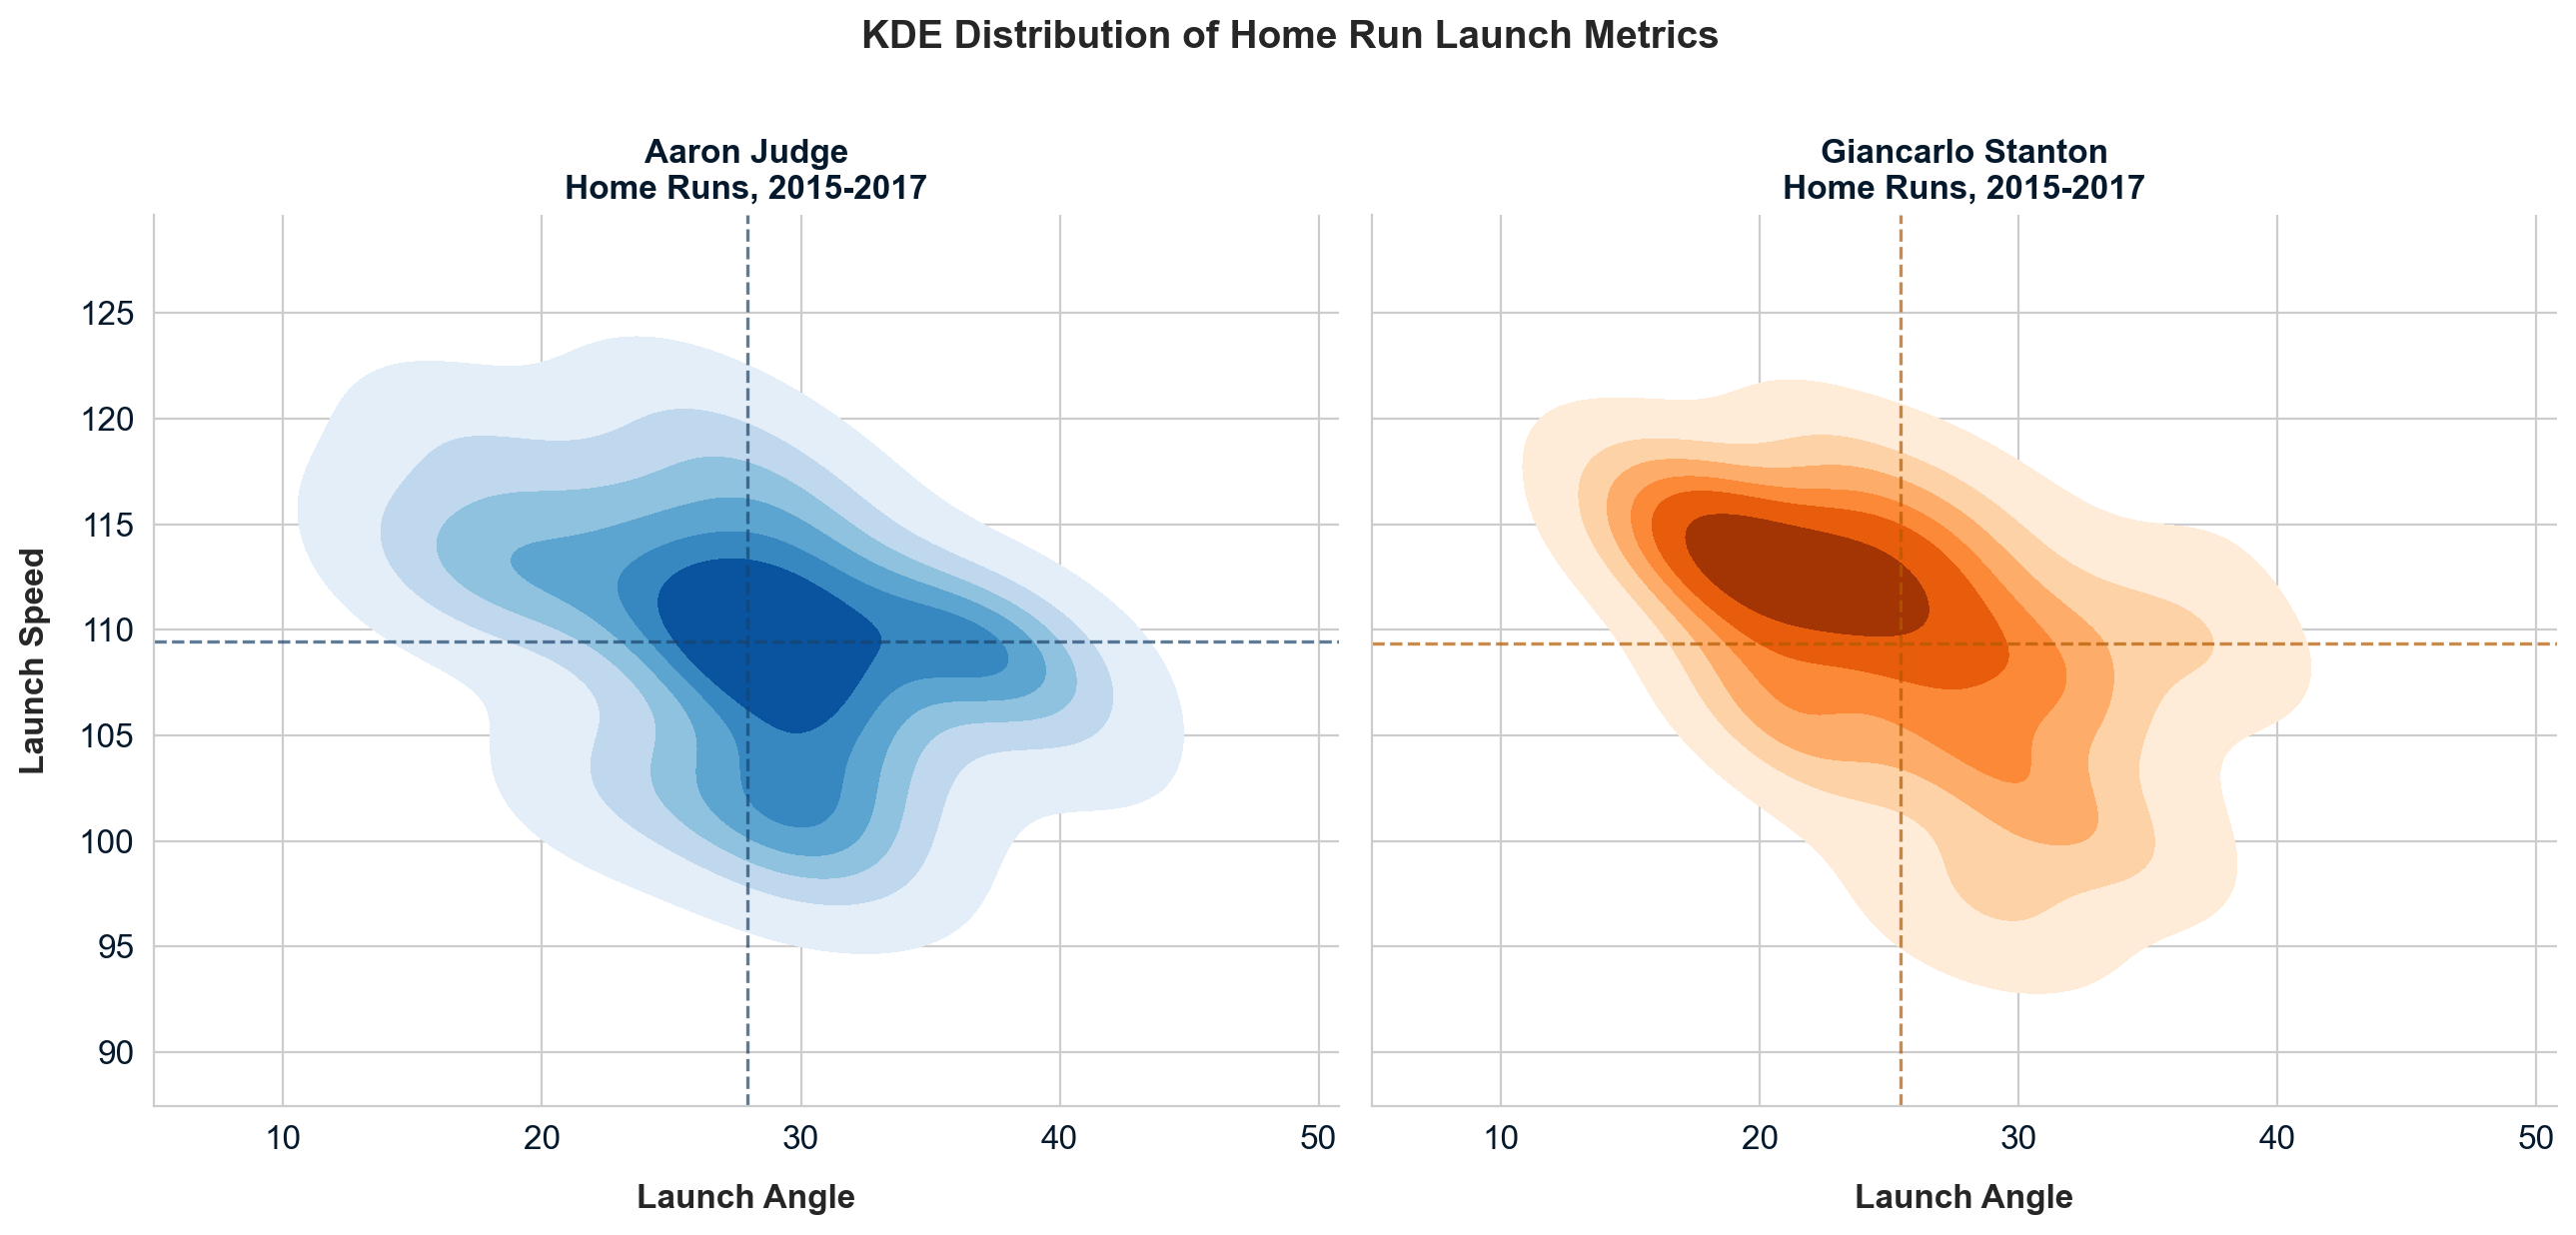

In [65]:
#============================================TASK 2=========================================
# Filter the datasets to isolate 'home_run' events for both players using independent copies
judge_home_runs = judge[judge["events"] == 'home_run'].copy()
stanton_home_runs = stanton[stanton["events"] == "home_run"].copy()

# Initialize side-by-side subplots with shared axes to maintain a consistent scale for evaluation
sns.set_style("whitegrid")
fig1, ax1 = plt.subplots(1, 2, figsize = (13,6), sharex = True, sharey = True)

# Generate a 2D KDE plot for Aaron Judge using a sequential blue color palette
# 'thresh=0.05' and 'levels=7' control density contour granularity and smooth out low-probability noise
sns.kdeplot(x=judge_home_runs.launch_angle, y=judge_home_runs.launch_speed,
            cmap="Blues", shade=True, shade_lowest=False, ax=ax1[0], 
            fill = True, thresh = 0.05, levels = 7)
ax1[0].set_title('Aaron Judge\nHome Runs, 2015-2017', fontsize=12, fontweight='bold')
ax1[0].set_xlabel('Launch Angle', fontsize=12, fontweight='bold', labelpad=10)
ax1[0].set_ylabel('Launch Speed', fontsize=12, fontweight='bold', labelpad=10)

# Add statistical reference lines representing the mean launch angle and speed for Judge
ax1[0].axvline(judge_home_runs['launch_angle'].mean(), color='#1a446c', 
               linestyle='--', linewidth=1.2, alpha=0.7)
ax1[0].axhline(judge_home_runs['launch_speed'].mean(), color='#1a446c', 
               linestyle='--', linewidth=1.2, alpha=0.7)

# Generate a 2D KDE plot for Giancarlo Stanton using a sequential orange color palette to keep visual identity
sns.kdeplot(x=stanton_home_runs.launch_angle, y=stanton_home_runs.launch_speed, 
            cmap="Oranges", shade=True, shade_lowest=False, ax=ax1[1], 
            fill = True, thresh = 0.05, levels = 7)
ax1[1].set_title('Giancarlo Stanton\nHome Runs, 2015-2017', fontsize=12, fontweight='bold')
ax1[1].set_xlabel('Launch Angle', fontsize=12, fontweight='bold', labelpad=10)
ax1[1].set_ylabel('') # Kept empty because sharey=True shares the vertical axis scale with the first plot

# Add statistical reference lines representing the mean launch angle and speed for Stanton
ax1[1].axvline(stanton_home_runs['launch_angle'].mean(), color='#b35900', linestyle='--', linewidth=1.2, alpha=0.7)
ax1[1].axhline(stanton_home_runs['launch_speed'].mean(), color='#b35900', linestyle='--', linewidth=1.2, alpha=0.7)

# Standardize tick label sizes across both subplots for clean and highly professional presentation
for ax in ax1:
    ax.tick_params(axis='both', labelsize=12)

# Set a comprehensive figure title, adjust spacing to avoid title overlaps, and strip top/right spines
plt.suptitle('KDE Distribution of Home Run Launch Metrics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
sns.despine(fig = fig1, top = True, right = True)
plt.show()

# Set variable to designate the player with the lower launch angle and harder hit distribution
player_hr = "Stanton"

### Section 2: Home Run Pitch Velocity Analysis
While absolute home run totals tell us how many times the ball cleared the fence, exploring the velocity of the incoming pitches tells us how these athletes leverage their reaction times. By isolating the release speed (`release_speed`) of every home run ball, we can map out each hitter's comfort zone against major league pitching.

#### Insights from the Distribution:
* **The High-Velocity Punisher (Aaron Judge):** The data reveals that Judge consistently thrives against higher internal velocities. His distribution, including a higher median marker, shows that he routinely turns fastballs and high-velocity pitches into deep scoring plays.
* **The Off-Speed Adjuster (Giancarlo Stanton):** While Stanton also punishes high heat, his overall distribution stretches lower, indicating a remarkable ability to stay back, adjust to off-speed pitches or breaking balls, and still generate enough leverage to drive them out of the park.


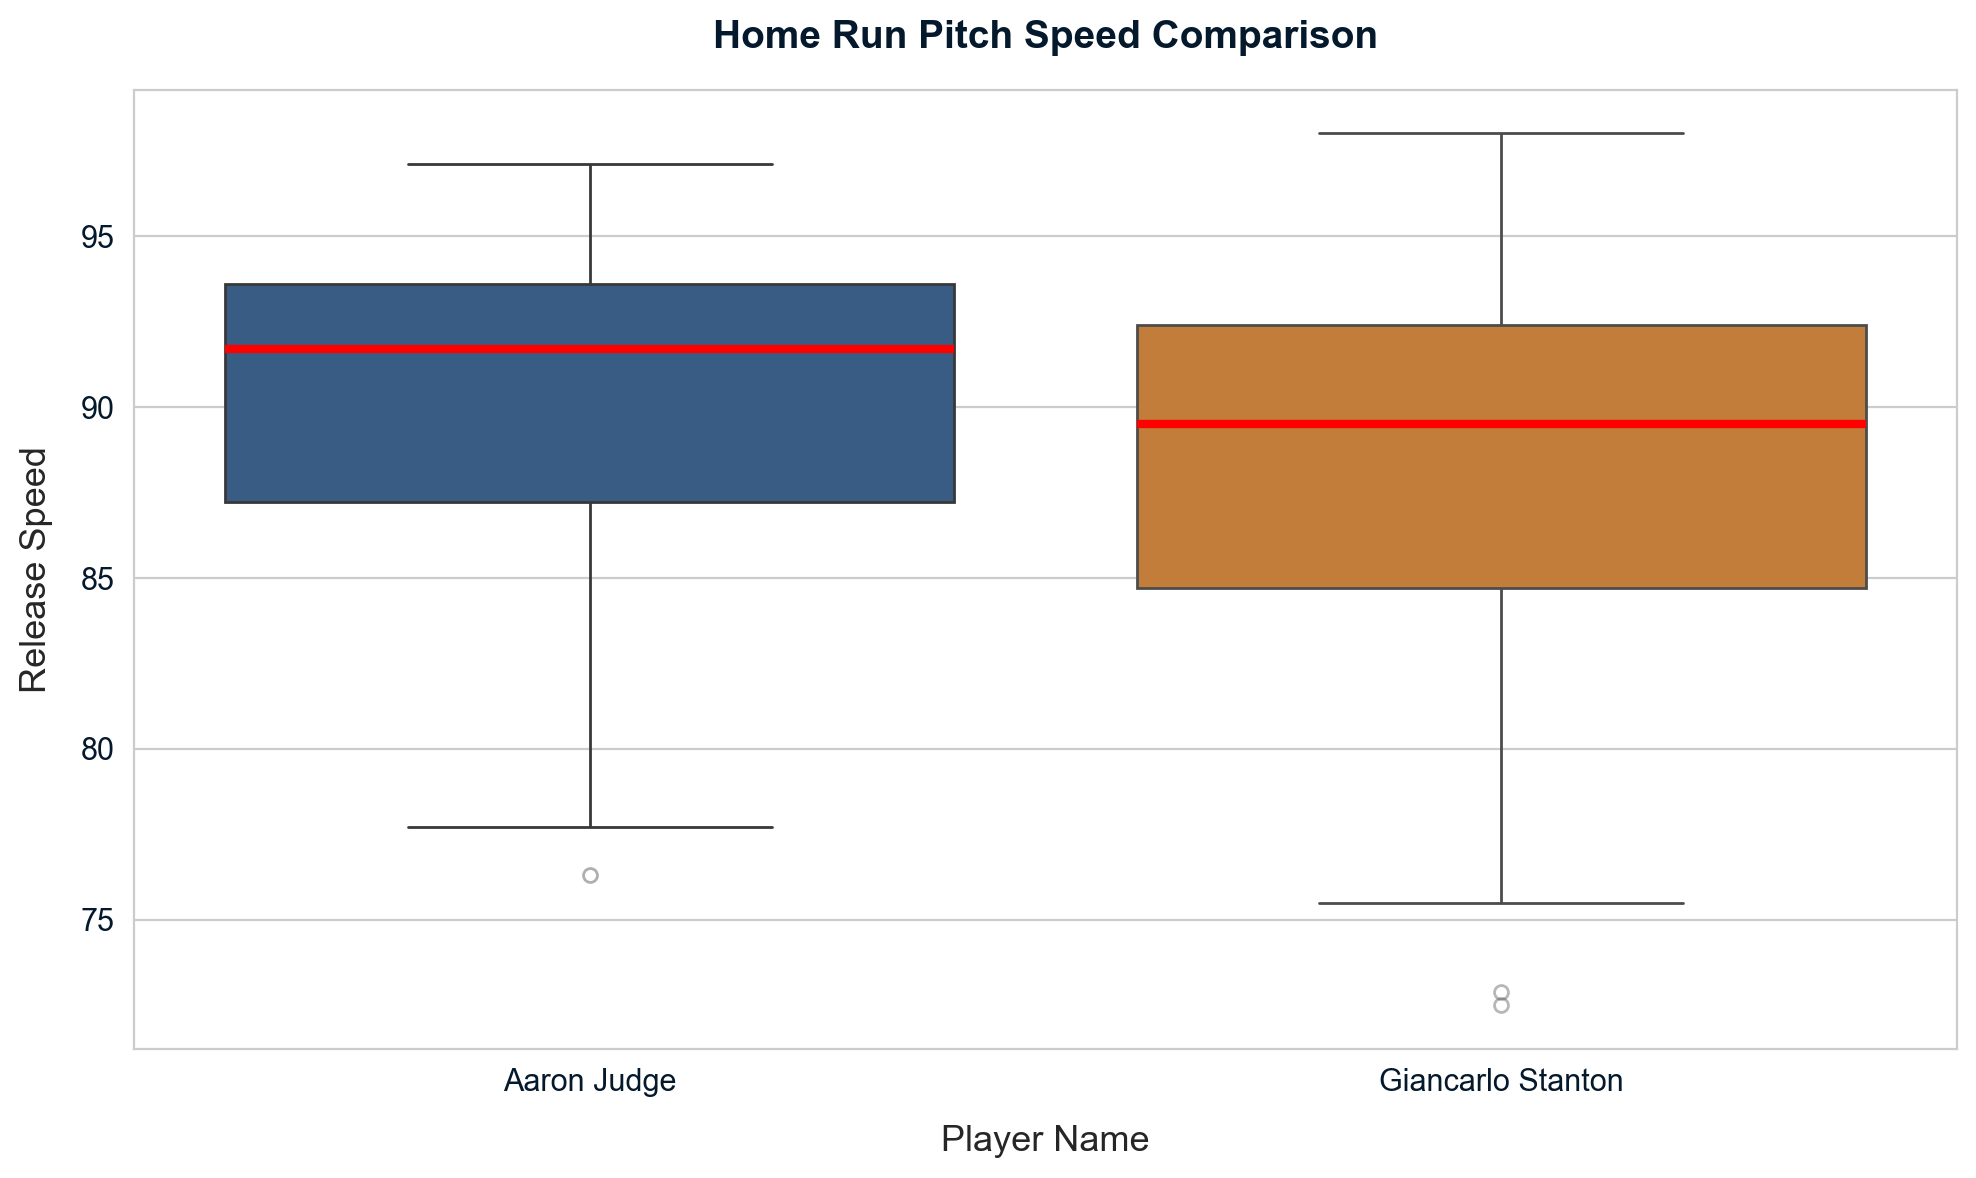

In [66]:
#============================================TASK 3=========================================
# Initialize a single plot figure with a standard layout for comparing distributions
plt.figure(figsize = (10, 6))

# Generate the boxplot distribution of pitch release speeds for Aaron Judge's home runs
# Custom blue palette maintains player branding; median and outliers are styled for high contrast
sns.boxplot(x = "player_name", 
            y = "release_speed", 
            data = judge_home_runs, 
            palette = {'Aaron Judge': '#2b5c8f'}, 
            medianprops = {'color': 'red', 'linewidth': 3.0}, 
            flierprops = {'marker': 'o', 'markersize': 5, 'alpha': 0.4})

# Overlay the boxplot distribution of pitch release speeds for Giancarlo Stanton's home runs
# Custom orange palette distinguishes the players while keeping identical statistical formatting
sns.boxplot(x = "player_name", 
            y = "release_speed", 
            data = stanton_home_runs, 
            palette = {'Giancarlo Stanton': '#d97d24'}, 
            medianprops = {'color': 'red', 'linewidth': 3.0}, 
            flierprops = {'marker': 'o', 'markersize': 5, 'alpha': 0.4})

# Configure labels, title, and adjust padding to deliver a polished presentation
plt.title('Home Run Pitch Speed Comparison', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Player Name', fontsize = 13, labelpad = 10)
plt.ylabel('Release Speed', fontsize = 13, labelpad = 10)

# Set tick label sizes across both axes for clear readability
plt.tick_params(axis = 'both', labelsize = 11)

# Apply tight layout to prevent any clipping of axis labels or titles
plt.tight_layout()
plt.show()

# Assign variable to track the player who hit home runs off higher median pitch velocities
player_fast = "Judge"

### Section 3: Spatial Heatmap Analysis of Home Run Strike Zones
This analysis maps the physical coordinate distribution of home runs across the 3x3 strike zone matrix. Pitches outside the standard strike zone boundaries (zones 11, 12, 13, and 14) are excluded to ensure focus on standard strike encounters. 

#### Spatial Density Observations:
* **Aaron Judge:** Demonstrates balanced coverage across the middle and lower sectors of the strike zone, with his absolute peak concentration (14 home runs) positioned dead-center.
* **Giancarlo Stanton:** Concentrates massive offensive production heavily toward the inside and lower-middle sections of the plate, racking up exceptional frequencies (23 and 19 home runs) in those specific quadrants. This demonstrates a distinct mechanical preference for low-and-in pitches.


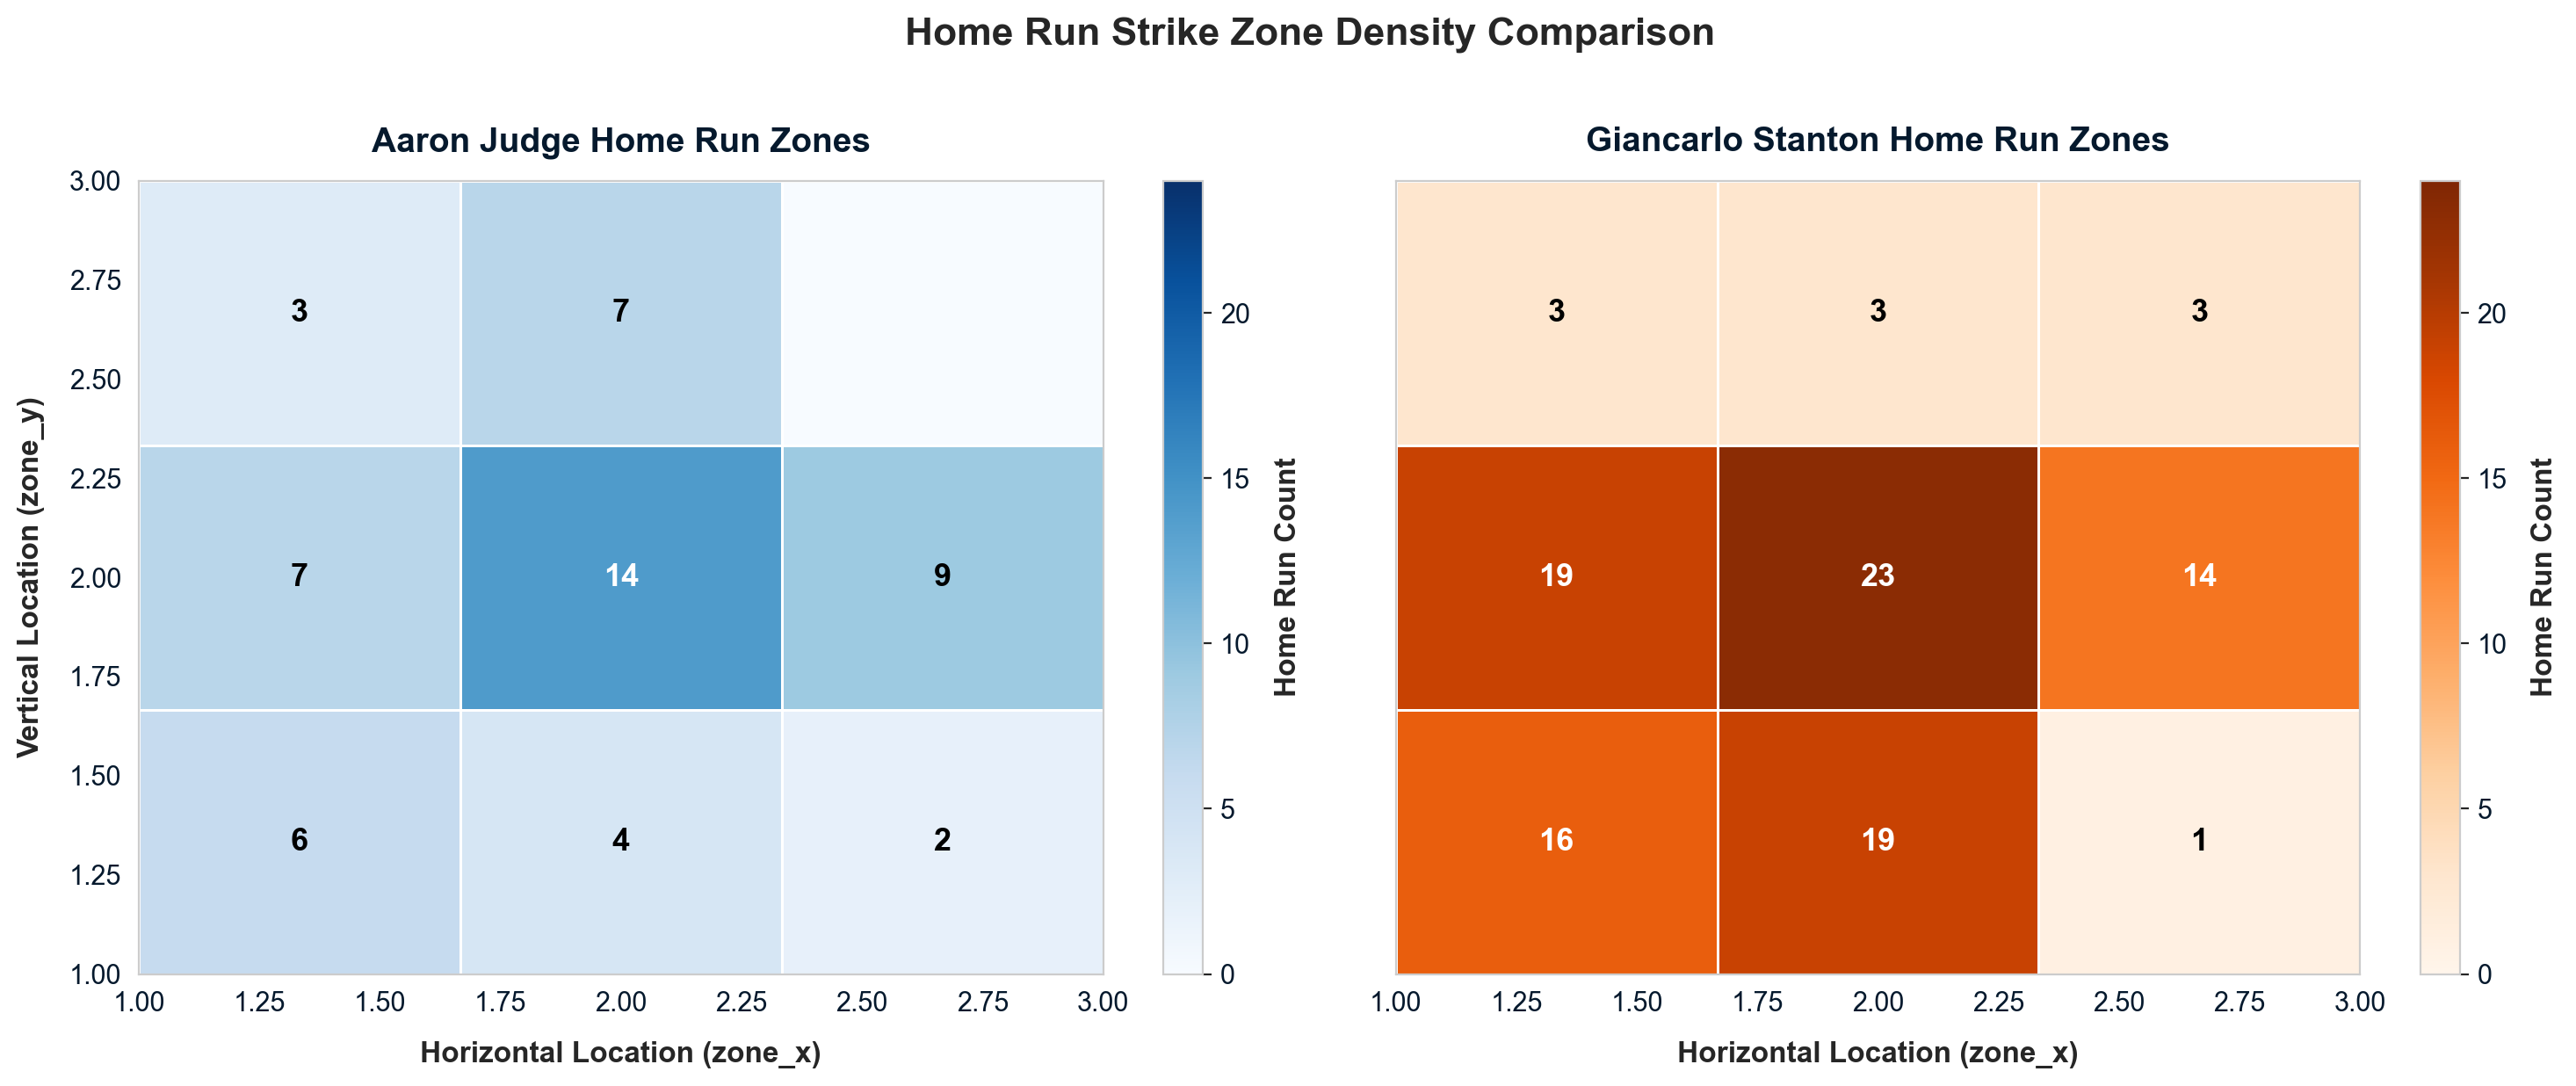

In [67]:
#============================================TASK 4=========================================
# Filter out non-strike zones (zones 11, 12, 13, and 14 represent pitches outside the strike zone strike boundary)
judge_strike_hr = judge_home_runs[~judge_home_runs['zone'].isin([11, 12, 13, 14])].copy()
stanton_strike_hr = stanton_home_runs[~stanton_home_runs['zone'].isin([11, 12, 13, 14])].copy()

# Map discrete strike zone categories into continuous Cartesian coordinates (X and Y) for spatial plotting
judge_strike_hr['zone_x'] = judge_strike_hr.apply(assign_x_coord, axis = 1)
judge_strike_hr['zone_y'] = judge_strike_hr.apply(assign_y_coord, axis = 1)
stanton_strike_hr['zone_x'] = stanton_strike_hr.apply(assign_x_coord, axis = 1)
stanton_strike_hr['zone_y'] = stanton_strike_hr.apply(assign_y_coord, axis = 1)

# Establish a uniform maximum scale cap (vmax) to guarantee a statistically valid baseline comparison
v_max = 24

# Set up side-by-side subplots with synchronized horizontal and vertical limits
fig, axs = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)

# ----------------- 1. Aaron Judge 2D Histogram -----------------
# Generate a 3x3 grid matching the strike zone matrix; apply the shared color scale limits via vmin/vmax
counts_j, xedges_j, yedges_j, im1 = axs[0].hist2d(judge_strike_hr['zone_x'], 
                                                  judge_strike_hr['zone_y'], 
                                                  bins=(3, 3), range=[[1, 3], [1, 3]], 
                                                  vmin=0, vmax=v_max, cmap='Blues', 
                                                  edgecolor='white', linewidth=1)
axs[0].set_title('Aaron Judge Home Run Zones', fontsize= 14, fontweight= 'bold', pad= 12)
axs[0].set_xlabel('Horizontal Location (zone_x)', fontsize= 12, fontweight= 'bold', labelpad= 10)
axs[0].set_ylabel('Vertical Location (zone_y)', fontsize=12, fontweight='bold', labelpad=10)

# Configure colorbar layout and label sizing for Judge
cbar1 = fig.colorbar(im1, ax= axs[0])
cbar1.set_label('Home Run Count', fontsize = 12, fontweight = 'bold', labelpad = 10)
cbar1.ax.tick_params(labelsize = 11)

# Superimpose frequency integers inside Judge's grid bins
for i in range(len(xedges_j)-1):
    for j in range(len(yedges_j)-1):
        if counts_j[i, j] > 0: 
            # Toggle text color dynamically based on bin density to ensure high visual contrast
            is_dark = counts_j[i, j] > (v_max / 2)
            axs[0].text((xedges_j[i] + xedges_j[i+1])/2, (yedges_j[j] + yedges_j[j+1])/2, 
                        int(counts_j[i, j]), color='white' if is_dark else 'black',
                        ha= 'center', va= 'center', fontweight= 'bold', fontsize= 13)

# ----------------- 2. Giancarlo Stanton 2D Histogram -----------------
# Replicate the identical 3x3 layout using a sequential orange palette to maintain visual player identity
counts_s, xedges_s, yedges_s, im2 = axs[1].hist2d(stanton_strike_hr['zone_x'], 
                                                  stanton_strike_hr['zone_y'], 
                                                  bins= (3, 3), range= [[1, 3], [1, 3]],
                                                  vmin= 0, vmax= v_max, cmap= 'Oranges', 
                                                  edgecolor= 'white', linewidth=1)
axs[1].set_title('Giancarlo Stanton Home Run Zones', fontsize= 14, fontweight= 'bold', pad= 12)
axs[1].set_xlabel('Horizontal Location (zone_x)', fontsize= 12, fontweight= 'bold', labelpad= 10)

# Configure colorbar layout and label sizing for Stanton
cbar2 = fig.colorbar(im2, ax=axs[1])
cbar2.set_label('Home Run Count', fontsize = 12, fontweight = 'bold', labelpad = 10)
cbar2.ax.tick_params(labelsize= 11)

# Superimpose frequency integers inside Stanton's grid bins
for i in range(len(xedges_s)-1):
    for j in range(len(yedges_s)-1):
        if counts_s[i, j] > 0:
            # Toggle text color dynamically based on bin density to ensure high visual contrast
            is_dark = counts_s[i, j] > (v_max / 2)
            axs[1].text((xedges_s[i] + xedges_s[i+1])/2, (yedges_s[j] + yedges_s[j+1])/2, 
                        int(counts_s[i, j]), color='white' if is_dark else 'black',
                        ha='center', va='center', fontweight='bold', fontsize=13)

# Enforce clean tick label visibility across both subplots
for ax in axs:
    ax.tick_params(axis='both', labelsize=11)

# Render global canvas title, optimize subplot margins, and display final figure
plt.suptitle('Home Run Strike Zone Density Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 🎯 The Analytical Verdict
Having analyzed the spatial configurations of the strike zone, pitch velocities, and aerodynamic launch metrics, we can synthesize our findings into a definitive structural profile for both elite sluggers.

While Stanton dominates the sheer velocity metrics and exhibits hyper-dense specialization in low-and-inside pitches, **Aaron Judge offers a more fundamentally balanced and high-carry home run profile**. Judge's ability to consistently find the optimal launch angle across a wider spatial distribution of the strike zone yields a more stable, versatile, and high-carry fly-ball profile—making his hitting mechanics the structurally preferred model for sustained home run production.